# 1. Environment Setup

In [60]:
import sys 
import subprocess
import pkgutil


# Required packages
required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'datasets': 'datasets',
    'pyarrow': 'pyarrow',
    'sklearn': 'scikit-learn',
    'tqdm': 'tqdm',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
}

print("Checking and installing missing dependencies... \n")
missing = []
for module_name, package_name in required_packages.items():
    if pkgutil.find_loader(module_name) is None:
        missing.append(package_name)

if missing:
    print(f"Installing missing packages: {','.join(missing)}. \n")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
    print("Installation complete. \n")
else:
    print("All dependencies already installed.\n")

Checking and installing missing dependencies... 

All dependencies already installed.



In [61]:
# Import Core Libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 2. Configuration

In [62]:
FEATURED_PARQUET = "../data/sourced/featured_reviews.parquet"

SAMPLED_PARQUET = "../data/processed/amazon_reviews_s10.parquet"
SAMPLED_CSV = "../data/processed/amazon_reviews_s10.csv"

SAMPLED_FRACTION = 0.1 # Sample 10% of the data for clustering
RANDOM_STATE = 42

FEATURES_FOR_CLUSTERING = [
    "review_length", 
    "image_bucket", 
    "days_since_first_review", 
    "is_verified",
    "rating_extremity",
]

# Features that are not included in clustering:
print("Features not used in clustering: images, combined_text")
print("Only metadata features are used for clustering as KMeans can only handle numerical data.\n")

Features not used in clustering: images, combined_text
Only metadata features are used for clustering as KMeans can only handle numerical data.



# 3. Load Source of Truth

In [63]:
# Load from feature file directly
if os.path.exists(FEATURED_PARQUET):
    try:
        df = pd.read_parquet(FEATURED_PARQUET)
        print(f"✓ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
        print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    except Exception as e:
        print(f"Error loading file: {e}")
else:
    print(f"✗ File not found: {FEATURED_PARQUET}")
    print(f"  Expected location: {os.path.abspath(FEATURED_PARQUET)}")

✓ Dataset loaded: 8,467,573 rows × 17 columns
  Memory usage: 5784.98 MB


In [64]:
df.head(2)

,rating,review_length,chars_per_word,image_bucket,days_since_first_review,is_verified,log_popularity,rating_extremity,question_mark,exclamation_mark,title_length,title_to_text_ratio,images,combined_text,is_helpful,helpful_vote,parent_asin
0,5,1112,5.4272,0 images,5115,1,4.499810,2,0,2,22,0.020183,[],Great laptop backpack! [SEP] I was searching f...,1,18,B001OC5JKY
1,5,1082,5.1321,0 images,8021,1,6.037871,2,0,0,33,0.031459,[],Love the headphones - great range [SEP] These ...,1,9,B09S6Y5BRG


## 3.1 Change the Categorical Data 'image_bucket' to ordinal encoding.

In [65]:
if "image_bucket" in df.columns:
    # Print the current dtype and values to diagnose
    print(f"Current dtype of 'image_bucket': {df['image_bucket'].dtype}")
    print(f"Unique values: {df['image_bucket'].unique()}")
    
    # Define the mapping
    image_bucket_map = {
        '0 images': 0,
        '1 image': 1,
        '2 images': 2,
        '3+ images': 3
    }
    
    # Convert categorical to string first
    df['image_bucket'] = df['image_bucket'].astype(str).map(image_bucket_map)
    
    # Check for NaNs in all clustering features
    nan_counts = df[FEATURES_FOR_CLUSTERING].isna().sum()
    if nan_counts.sum() > 0:
        print(f"\nNaN counts by feature:")
        print(nan_counts[nan_counts > 0])
    
    print("✓ 'image_bucket' successfully mapped to numeric values for clustering.")
    print("  Mapping: '0 images'→0, '1 image'→1, '2 images'→2, '3+ images'→3")
    print(f"\nValue counts after mapping:\n{df['image_bucket'].value_counts().sort_index()}")
else:
    print("⚠️ 'image_bucket' column not found in dataset")

Current dtype of 'image_bucket': category
Unique values: ['0 images', '3+ images', '2 images', '1 image']
Categories (4, str): ['0 images' < '1 image' < '2 images' < '3+ images']
✓ 'image_bucket' successfully mapped to numeric values for clustering.
  Mapping: '0 images'→0, '1 image'→1, '2 images'→2, '3+ images'→3

Value counts after mapping:
image_bucket
0    7734572
1     385137
2     165461
3     182403
Name: count, dtype: int64


## 3.2 Check if all the features considered for clustering are numeric

In [66]:
features = df.select_dtypes(include=[np.number]).columns.tolist()

for feat in FEATURES_FOR_CLUSTERING:
    if feat not in features:
        print(f"⚠️ Warning: Feature '{feat}' not found in dataset. Not a numeric feature, so it should be skipped in clustering.")
    else:
        print(f"✓ Feature '{feat}' is numeric and will be included in clustering.")

✓ Feature 'review_length' is numeric and will be included in clustering.
✓ Feature 'image_bucket' is numeric and will be included in clustering.
✓ Feature 'days_since_first_review' is numeric and will be included in clustering.
✓ Feature 'is_verified' is numeric and will be included in clustering.
✓ Feature 'rating_extremity' is numeric and will be included in clustering.


# 4. Clustering

Clustering is performed to **group reviews by behavioral patterns** (rating, helpful votes, review length, verified purchase) so that when we reduce the dataset, we **retain diverse review types** and avoid losing rare but important examples. This ensures the final dataset is **representative of the original population** before sampling.

Create new substitute features for KMeans to work

In [67]:
features = FEATURES_FOR_CLUSTERING

df_kmeans = df[features].copy()
print("Dataframe for clustering:")
df_kmeans.head(2)

Dataframe for clustering:


,review_length,image_bucket,days_since_first_review,is_verified,rating_extremity
0,1112,0,5115,1,2
1,1082,0,8021,1,2


In [68]:
# Stardardiz the features for better clustering performance
scaler = StandardScaler()
df_kmeans_scaled = scaler.fit_transform(df_kmeans)

### 4.1 Check silhouette score for range of k: [2, 15]

In [69]:
inertia = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    print(f"Running KMeans for k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(df_kmeans_scaled)
    inertia.append(kmeans.inertia_)

    sample_idx = np.random.choice(len(df_kmeans_scaled), 100_000, replace=False)
    df_kmeans_sample = df_kmeans_scaled[sample_idx]
    labels_sample = labels[sample_idx]

    sil_score = silhouette_score(df_kmeans_sample, labels_sample)
    sil_scores.append(sil_score)

    print(f"  Inertia for {k} clusters: {inertia[-1]:.2f}")
    print(f"  Silhouette Score for {k} clusters: {sil_score:.4f}")

Running KMeans for k=2...
  Inertia for 2 clusters: 32796124.62
  Silhouette Score for 2 clusters: 0.4966
Running KMeans for k=3...
  Inertia for 3 clusters: 26115238.05
  Silhouette Score for 3 clusters: 0.5157
Running KMeans for k=4...
  Inertia for 4 clusters: 19888172.05
  Silhouette Score for 4 clusters: 0.4142
Running KMeans for k=5...
  Inertia for 5 clusters: 16948029.80
  Silhouette Score for 5 clusters: 0.3661
Running KMeans for k=6...
  Inertia for 6 clusters: 13936482.65
  Silhouette Score for 6 clusters: 0.3733
Running KMeans for k=7...
  Inertia for 7 clusters: 12768948.79
  Silhouette Score for 7 clusters: 0.3694
Running KMeans for k=8...
  Inertia for 8 clusters: 11944832.13
  Silhouette Score for 8 clusters: 0.3808
Running KMeans for k=9...
  Inertia for 9 clusters: 11812316.20
  Silhouette Score for 9 clusters: 0.4004
Running KMeans for k=10...
  Inertia for 10 clusters: 10949962.41
  Silhouette Score for 10 clusters: 0.4002


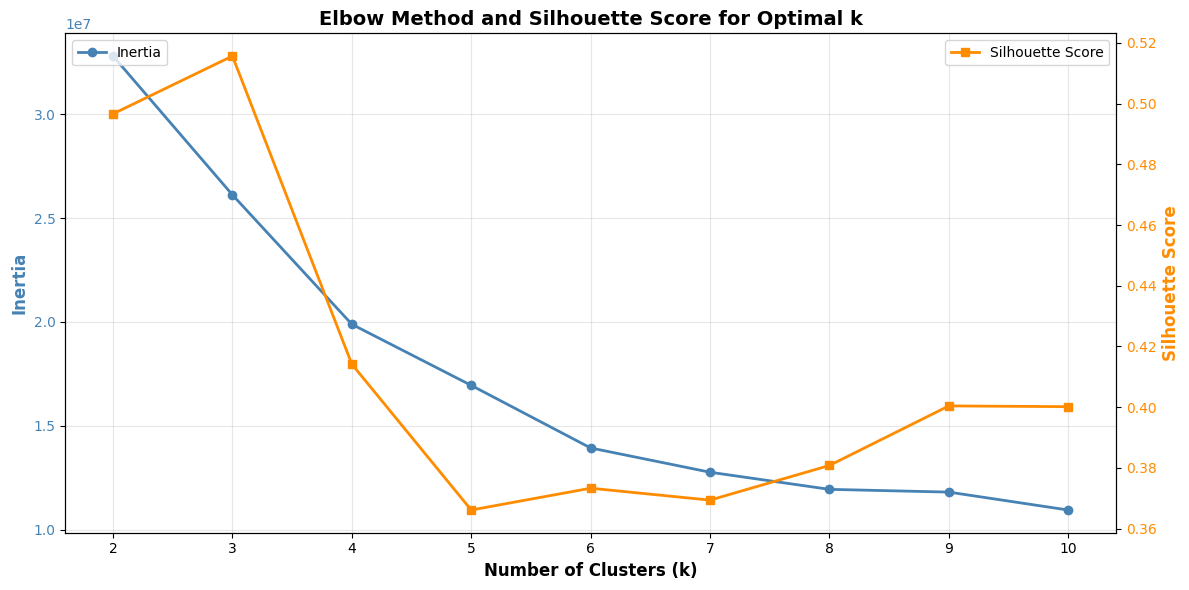

In [70]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Elbow Curve on left y-axis
ax1.plot(k_range, inertia, 'o-', color='steelblue', linewidth=2, markersize=6, label='Inertia')
ax1.set_xlabel('Number of Clusters (k)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Inertia', color='steelblue', fontweight='bold', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(True, alpha=0.3)

# Create second y-axis for Silhouette Score using twinx()
ax2 = ax1.twinx()
ax2.plot(k_range, sil_scores, 's-', color='darkorange', linewidth=2, markersize=6, label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='darkorange', fontweight='bold', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkorange')

# Title and legends
plt.title('Elbow Method and Silhouette Score for Optimal k', fontweight='bold', fontsize=14)
ax1.legend(loc='upper left', fontsize=10)
ax2.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

Although *k = 3* yields a slightly higher silhouette score than *k = 2*, the score drops significantly at *k = 4*; therefore, *k = 3* is selected as the optimal number of clusters.

Reasoning:

Highest Silhouette Score occurs at k = 3 (0.5157) → best cluster separation and cohesion.
After k = 3, the silhouette score drops sharply at k = 4 (0.4142), indicating over-segmentation.
Although inertia keeps decreasing (expected behavior), the quality of clustering worsens beyond k = 3.
The slight elbow at k = 4 is weaker evidence compared to the clear silhouette optimum at k = 3.

### 4.2 Create clusters with best k

In [71]:
num_clusters = int(input("Based on the Elbow and Silhouette analysis, enter the optimal number of clusters (k): "))
# num_clusters = 6

kmeans = KMeans(n_clusters=num_clusters, random_state=RANDOM_STATE)
df_kmeans['cluster_kmeans'] = kmeans.fit_predict(df_kmeans_scaled)

### 4.3 Visualization of clusters

#### Graphs to check different sides of the kmeans clusters

In [72]:
def generate_feature_pairs(features_list, max_pairs=20):
    """
    Automatically generate meaningful feature pairs for visualization.
    Priority: target variable pairings, then complementary relationships.
    """
    pairs = []
    
    # Priority: Add complementary feature-to-feature pairs
    complementary = [
        ('review_length', 'image_bucket'),
        ('review_length', 'days_since_first_review'),
        ('review_length', 'is_verified'),
        ('review_length', 'rating_extremity'),
        ('image_bucket', 'days_since_first_review'),
        ('image_bucket', 'is_verified'),
        ('image_bucket', 'rating_extremity'),
        ('days_since_first_review', 'is_verified'),
        ('days_since_first_review', 'rating_extremity'),
        ('is_verified', 'rating_extremity'),
    ]
    
    for x, y in complementary:
        if len(pairs) < max_pairs and all(f in features_list for f in [x, y]):
            if (x, y) not in pairs and (y, x) not in pairs:
                pairs.append((x, y))
    
    return pairs[:max_pairs]

# Generate feature pairs automatically
feature_pairs = generate_feature_pairs(FEATURES_FOR_CLUSTERING, max_pairs=16)

print(f"Generated {len(feature_pairs)} feature pairs for visualization")

Generated 10 feature pairs for visualization


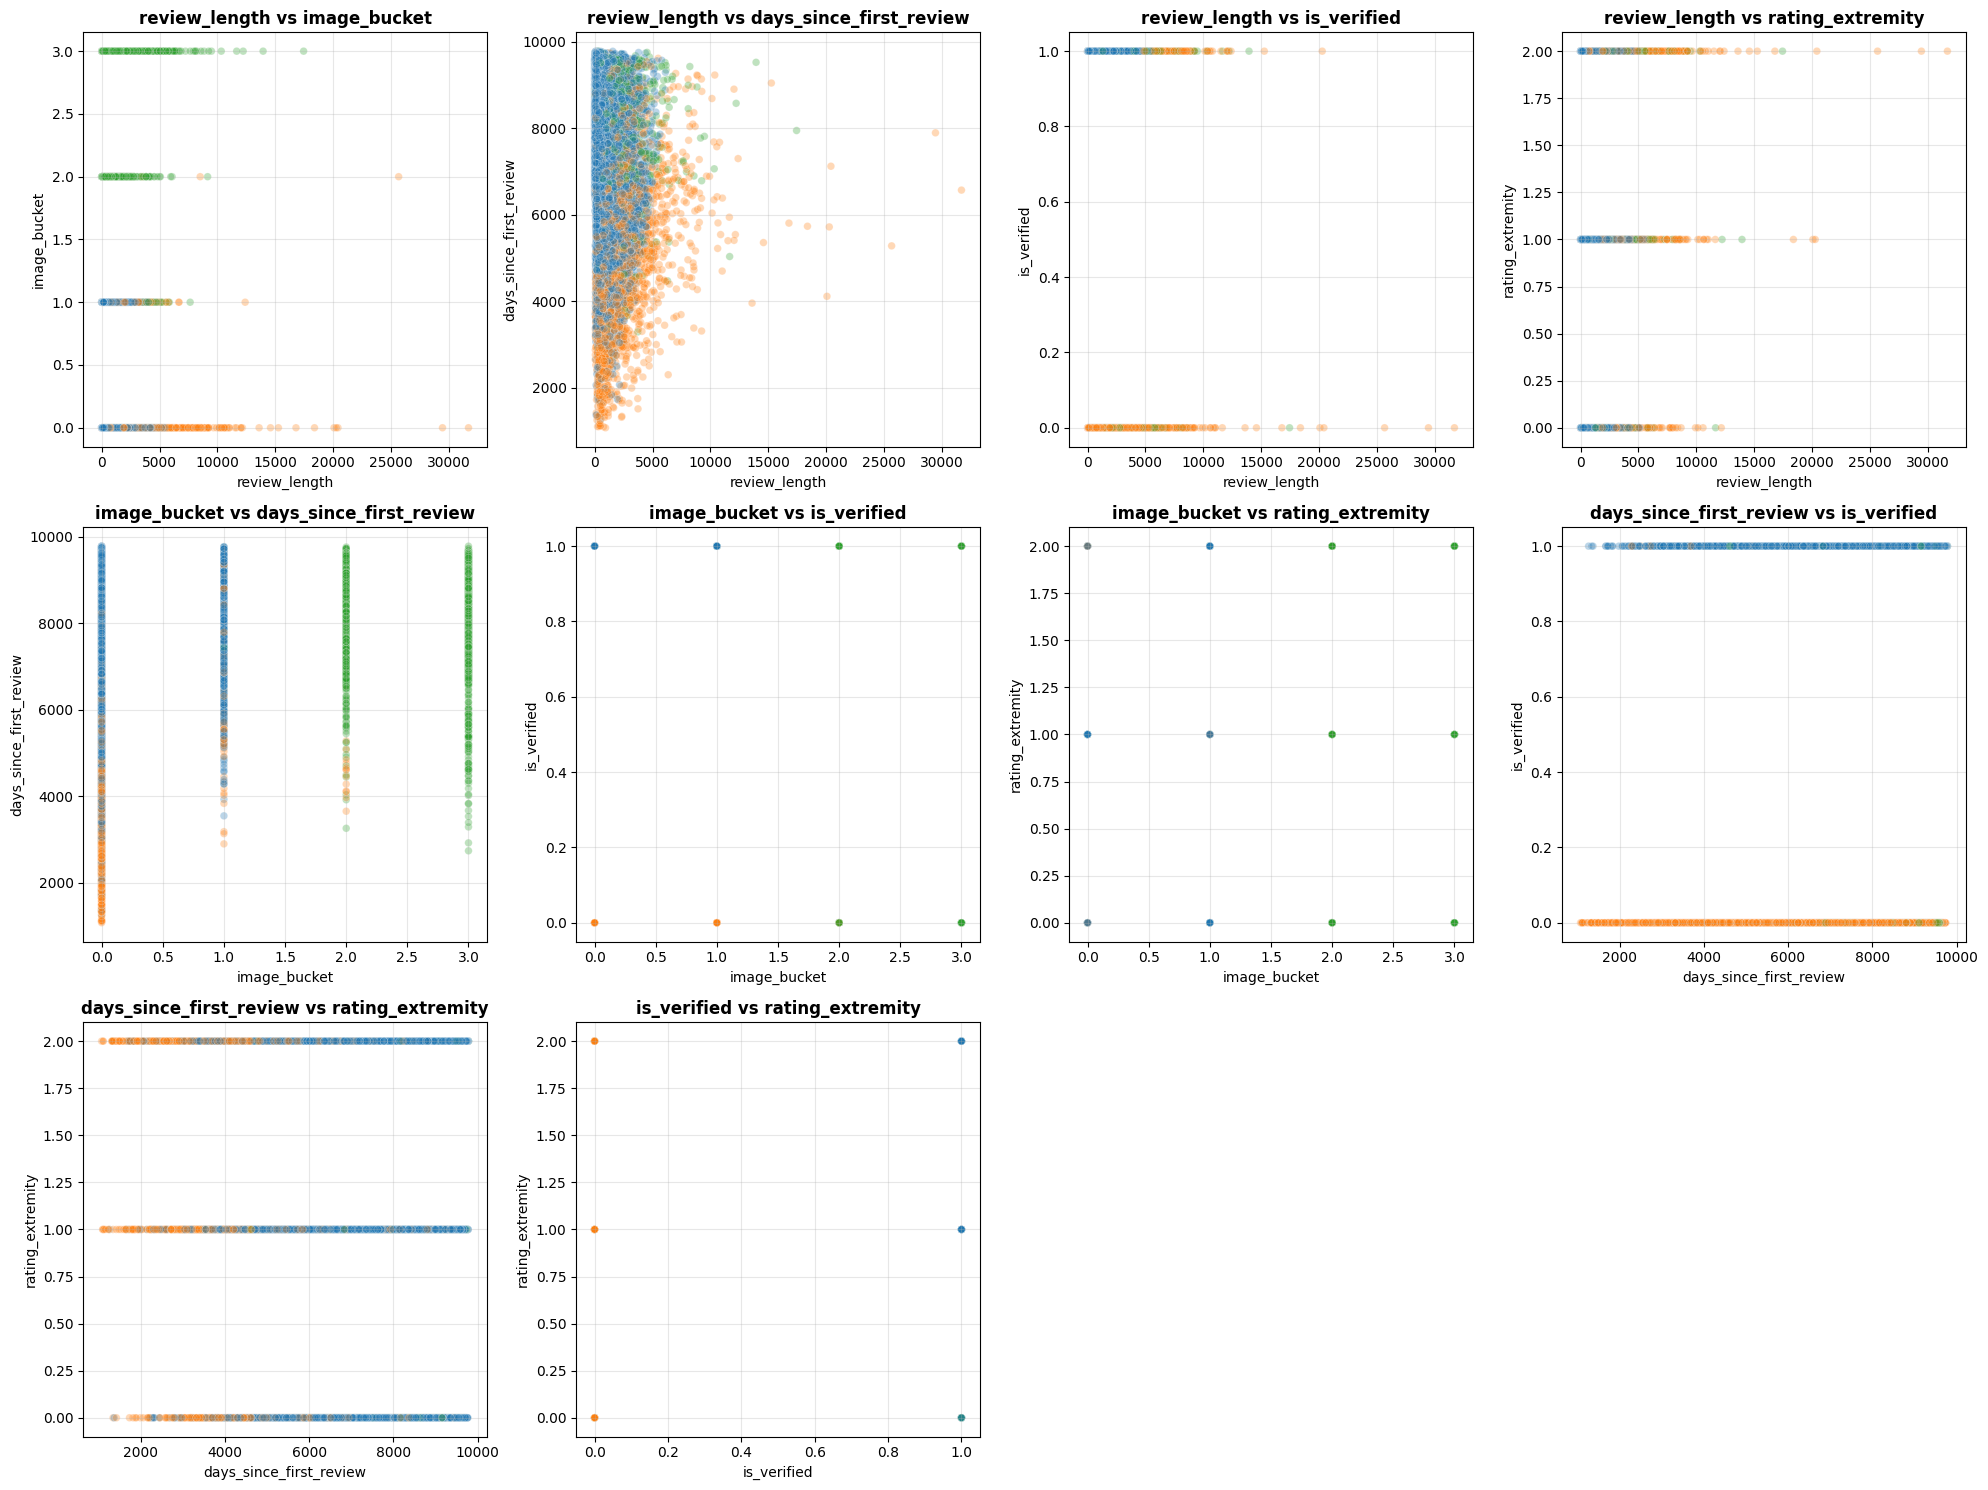

In [73]:
# Auto-calculate grid dimensions
num_pairs = len(feature_pairs)
cols = 4
rows = (num_pairs + cols - 1) // cols

viz_df = df_kmeans.sample(n=100_000, random_state=RANDOM_STATE)

fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
axes = axes.flatten()

for i, (x_feat, y_feat) in enumerate(feature_pairs):
    sns.scatterplot(
        data=viz_df,
        x=x_feat,
        y=y_feat,
        hue='cluster_kmeans',
        palette='tab10',
        alpha=0.3,
        s=30,
        ax=axes[i],
        legend=False
    )
    axes[i].set_title(f"{x_feat} vs {y_feat}", fontweight='bold')
    axes[i].grid(True, alpha=0.3)

# Remove empty subplots
for j in range(len(feature_pairs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### 3D PCA Visualization of Clusters

Reduce 13 clustering features to 3 principal components for interactive cluster visualization in 3D space. This helps identify cluster separation and reveal any overlapping regions.

Text(0.5, 0, 'PCA Component 3')

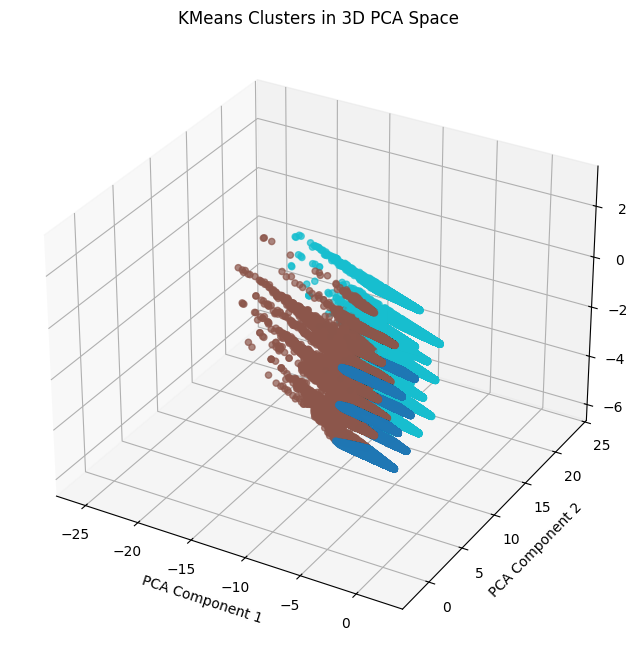

In [74]:
pca3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca = pca3d.fit_transform(df_kmeans_scaled)


# 3D Scatter Plot of PCA Components colored by KMeans clusters
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
    c = df_kmeans['cluster_kmeans'],
    cmap = 'tab10',
    s = 20,
    alpha = 0.7
)

ax.set_title('KMeans Clusters in 3D PCA Space')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')

#### Cluster Portfolio & Behavioral Profiles

Summarize cluster characteristics across all clustering features. Compute mean, median, and proportions for each cluster to understand behavioral patterns and review characteristics within each group.

In [75]:
# CLUSTER PORTFOLIO / PROFILE

# Number of samples per cluster
cluster_size = df_kmeans.groupby('cluster_kmeans').size().rename("count")

# Percentage share of each cluster
cluster_percentage = (
    df_kmeans['cluster_kmeans']
    .value_counts(normalize=True)
    .sort_index() * 100
).rename("percentage")

# Behavioural statistics per cluster
cluster_profile = df_kmeans.groupby('cluster_kmeans').agg({
    'review_length': ['mean', 'median'],
    'image_bucket': ['mean', 'median'],
    'days_since_first_review': ['mean', 'median'],
    'is_verified': 'mean',
    'rating_extremity': ['mean', 'median'],
})

# Combine everything
cluster_portfolio = pd.concat(
    [cluster_size, cluster_percentage, cluster_profile],
    axis=1
)

cluster_portfolio

,count,percentage,"(review_length, mean)","(review_length, median)","(image_bucket, mean)","(image_bucket, median)","(days_since_first_review, mean)","(days_since_first_review, median)","(is_verified, mean)","(rating_extremity, mean)","(rating_extremity, median)"
cluster_kmeans,,,,,,,,,,,
0,7203984,85.077318,455.674835,291.0,0.048552,0.0,7690.666997,7778.0,1.000000,1.633100,2.0
1,914978,10.805670,1024.116686,598.0,0.038700,0.0,6339.405412,6460.0,0.017973,1.566650,2.0
2,348611,4.117012,869.130790,528.0,2.518816,3.0,8374.137205,8615.0,0.866387,1.699568,2.0


### 4.4 Summary

| Cluster | Meaning                  | Sampling value     |
| ------- | ------------------------ | ------------------ |
| 0       | Normal reviews           | majority baseline  |
| 1       | Long unverified opinions | rare behavior      |
| 2       | Image-heavy reviews      | very rare behavior |
---

Cluster 0 — 85% of data
Short reviews (mean ≈ 456)
Almost all verified purchases
Almost no images
Older reviews
Extreme ratings

Interpretation
→ Typical Amazon review

This is the baseline population.

---

Cluster 1 — 10.8%
Longest reviews (mean ≈ 1024)
Almost all unverified
Few images
Slightly newer

Interpretation
→ Essay-style / opinion-heavy / possibly external users

These are:
non-verified reviewers
long textual opinions
different behavioral intent
This cluster is meaningful.

---
Cluster 2 — 4.1%
Many images (median = 3)
Long reviews
Mostly verified
Older products

Interpretation
→ Media-rich reviewers

These are:
photo reviewers
demonstrators
showcase reviewers
Also, meaningful.


# 5. Sampling

Sampling by a single feature like rating or parent_asin preserves only one dimension of the data distribution, while real review behaviour depends on multiple interacting factors (rating, helpfulness, review length, purchase verification).
Cluster-based sampling captures these multivariate behavioural patterns simultaneously instead of enforcing artificial balance along one column.
Therefore, clustering maintains the natural joint structure of the dataset rather than oversimplifying representativeness to a single feature.

While the paper’s deterministic uniformity minimizes variance for structural reliability, our use of stratified random sampling ensures the dataset retains the "stochastic noise" and "edge cases" necessary for a robust AI model. By capturing these rare, unique points within each cluster, we may see lower metrics during training, but we ensure the model generalizes better to the messy, unpredictable nature of real-world consumer data.

**Paper:**\
Song, J. and Xu, J. (2024) ‘A clustering-based partially stratified sampling for high-dimensional structural reliability assessment’, Computers and Structures, 299, 107390. doi: 10.1016/j.compstruc.2024.107390.

In [76]:
df['cluster_kmeans'] = df_kmeans['cluster_kmeans']

In [77]:
sampled_df = (
    df
    .groupby('cluster_kmeans', as_index=False)
    .sample(frac=SAMPLED_FRACTION, random_state=RANDOM_STATE)
)

# Check the dtypes of the sampled dataframe
print(f"Dtypes in sampled dataframe: \n{sampled_df.dtypes}")
print(f"Sampled dataframe shape: {sampled_df.shape}")

Dtypes in sampled dataframe: 
rating                         int8
review_length                 int32
chars_per_word              float64
image_bucket                  int64
days_since_first_review       int32
is_verified                    int8
log_popularity              float64
rating_extremity               int8
question_mark                 int16
exclamation_mark              int16
title_length                  int16
title_to_text_ratio         float32
images                       object
combined_text                   str
is_helpful                     int8
helpful_vote                  int32
parent_asin                category
cluster_kmeans                int32
dtype: object
Sampled dataframe shape: (846757, 18)


In [78]:
print("Original size:", len(df))
print("Sampled size:", len(sampled_df))

print("\nOriginal cluster distribution:")
print(df['cluster_kmeans'].value_counts(normalize=True))

print("\nSampled cluster distribution:")
print(sampled_df['cluster_kmeans'].value_counts(normalize=True))

Original size: 8467573
Sampled size: 846757

Original cluster distribution:
cluster_kmeans
0    0.850773
1    0.108057
2    0.041170
Name: proportion, dtype: float64

Sampled cluster distribution:
cluster_kmeans
0    0.850773
1    0.108057
2    0.041170
Name: proportion, dtype: float64


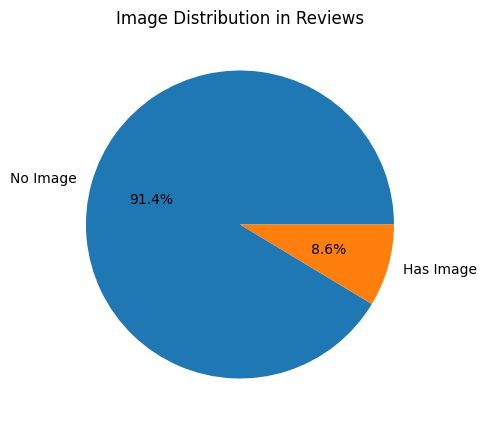


📸 Image Distribution:
  Has Image: 733,001 reviews (8.7%)
  No Image: 7,734,572 reviews (91.3%)


In [79]:
# Image Distribution
plt.figure(figsize=(8,5))
has_image = sampled_df['images'].map(len).gt(0).value_counts()

plt.pie(
    has_image.values,
    labels=['Has Image' if i else 'No Image' for i in has_image.index],
    autopct='%1.1f%%'
)
plt.title('Image Distribution in Reviews')
plt.show()

image_counts = (
    df["images"]
    .astype(str)
    .apply(lambda x: x != "[]" and x != "nan")
    .value_counts()
)
print(f"\n📸 Image Distribution:")
print(f"  Has Image: {image_counts.get(True, 0):,} reviews ({image_counts.get(True, 0)/len(df)*100:.1f}%)")
print(f"  No Image: {image_counts.get(False, 0):,} reviews ({image_counts.get(False, 0)/len(df)*100:.1f}%)")

# 6. Export as Parquet

**📚 Understanding Parquet Format** 

The following resources helped in understanding **why Parquet is used for dataset export**.  

- [What is Parquet? (YouTube)](https://youtu.be/KLFadWdomyI?si=4RM2NXcPo147rxec)
- [Parquet Explained — Short Overview](https://youtube.com/shorts/-f8rs4A_MHA?si=6-XsfKYL3jbt_zy3)

These videos provide a quick conceptual understanding of columnar storage and performance advantages relevant to our pipeline.

**Why Use Parquet Format**

- Columnar storage format → significantly smaller file size than CSV  
- Faster read and write performance for large datasets  
- More memory-efficient loading during analysis and modelling  
- Requires no database server or configuration  
- Loads instantly into pandas, Spark, and ML pipelines  
- Preserves datatypes natively (no re-parsing needed)  
- Avoids schema loss and datatype inconsistencies common in CSV files

In [80]:
print(f"Dataset shape before export: {sampled_df.shape[0]:,} rows x {sampled_df.shape[1]:,} columns")
print(f"Memory usage before export: {sampled_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("Dataset preview before export:")
sampled_df.head(2)

Dataset shape before export: 846,757 rows x 18 columns
Memory usage before export: 599.07 MB
Dataset preview before export:


,rating,review_length,chars_per_word,image_bucket,days_since_first_review,is_verified,log_popularity,rating_extremity,question_mark,exclamation_mark,title_length,title_to_text_ratio,images,combined_text,is_helpful,helpful_vote,parent_asin,cluster_kmeans
6016223,5,439,5.1744,0,9163,1,2.079442,2,0,5,27,0.065534,[],Incredibly rigid and strong [SEP] We have a 60...,0,1,B07RHQJT1V,0
920218,1,1600,5.1974,0,5207,1,2.397895,2,0,0,14,0.008827,[],Don't Buy This [SEP] This is one of the worst ...,1,4,B003D78O1Y,0


In [81]:
dropped_features = [ 
    'cluster_kmeans'
]

for feature in dropped_features:
    if feature in sampled_df.columns:
        sampled_df.drop(columns=[feature], inplace=True)

print(f"\nDataset shape after dropping features: {sampled_df.shape[0]:,} rows x {sampled_df.shape[1]:,} columns")


Dataset shape after dropping features: 846,757 rows x 17 columns


In [82]:
# Export the dataset
sampled_df.to_parquet(SAMPLED_PARQUET, index=False)
print(f"Sampled dataset exported to '{SAMPLED_PARQUET}'")

Sampled dataset exported to '../data/processed/amazon_reviews_s10.parquet'


In [83]:
# Export as CSV for size comparison
sampled_df.to_csv(SAMPLED_CSV, index=False)
print(f"Sampled dataset exported to '{SAMPLED_CSV}'")

Sampled dataset exported to '../data/processed/amazon_reviews_s10.csv'


In [84]:
parquet_size = os.path.getsize(SAMPLED_PARQUET) / 1024**2
csv_size = os.path.getsize(SAMPLED_CSV) / 1024**2

print(f"Parquet size: {parquet_size:.2f} MB")
print(f"CSV size: {csv_size:.2f} MB")
print(f"Compression gain: {csv_size / parquet_size:.2f}x smaller")

Parquet size: 288.46 MB
CSV size: 547.09 MB
Compression gain: 1.90x smaller


In [85]:
# Delete CSV file (keep only Parquet as source of truth)
if os.path.exists(SAMPLED_CSV):
    os.remove(SAMPLED_CSV)
    print(f"CSV file deleted: '{SAMPLED_CSV}'")
else:
    print(f"CSV file not found: '{SAMPLED_CSV}'")

CSV file deleted: '../data/processed/amazon_reviews_s10.csv'


**Data Dictionary — Clustering Features**

| Feature | Description | Data Type |
|---|---|---|
| `rating` | Star rating given by the reviewer (1–5 scale) | int8 |
| `review_length` | (NF) Length of review text measured in characters | int64 |
| `char_per_word` | (NF) Average characters per word (text complexity indicator) | float32 |
| `image_bucket` | (NF) Number of images attached to review (ordinal: 0→1→2→3+) | int8 |
| `days_since_first_review` | (NF) Number of days elapsed since earliest review in dataset | int32 |
| `is_verified` | (NF) Binary indicator of verified purchase | int8 |
| `log_popularity` | (NF) Log-transformed product review count (ASIN-level activity) | float32 |
| `rating_extremity` | (NF) How extreme the rating is relative to neutral (1-5 scale distance) | float32 |
| `question_mark` | (NF) Count or density of question marks in review text | int16 |
| `exclamation_mark` | (NF) Count or density of exclamation marks in review text | int16 |
| `title_length` | (NF) Character count of review title | int16 |
| `title_to_text_ratio` | (NF) Ratio of title length to review text length | float32 |
| `is_helpful` | Target variable: Binary indicator of review helpfulness | int8 |

**Note:** (NF) denotes Engineered Features created during feature engineering pipeline.